# Part B — Deep Learning Architectures

## B3: Recurrent Neural Network (RNN/LSTM)
### Daily Temperature Sequence Prediction

This project implements and compares SimpleRNN and LSTM models for time-series sequence prediction.

The objective is to predict the next day's minimum temperature using the previous 10 days of temperature data.

### Dataset
- Dataset: Daily Minimum Temperatures in Melbourne
- Time Period: 1981–1990
- Task: Time-Series Sequence Prediction
- Input: Previous 10 time steps
- Output: Next time step

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Load dataset
df = pd.read_csv("daily-min-temperatures.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Set Date as index
df.set_index("Date", inplace=True)

# Display dataset information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (3650, 1)

First 5 rows:


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8



Missing Values:
Temp    0
dtype: int64


## Step 2: Data Visualization

The temperature data is visualized to observe its variations over time and identify seasonal patterns.


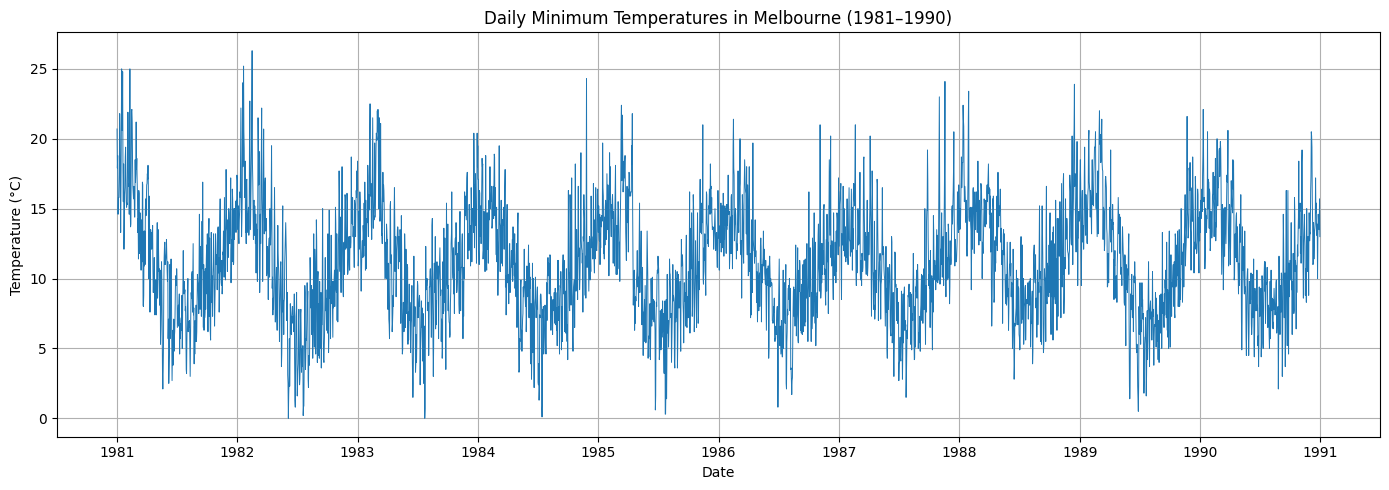

In [3]:
plt.figure(figsize=(14, 5))

plt.plot(df.index, df["Temp"], linewidth=0.7)

plt.title("Daily Minimum Temperatures in Melbourne (1981–1990)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 3: Train-Test Split

The dataset is divided into training and testing sets while preserving the chronological order.

The first 80% of the data is used for training, and the remaining 20% is used for testing.

In [4]:
# Split data chronologically
split_index = int(len(df) * 0.8)

train_data = df["Temp"].iloc[:split_index]
test_data = df["Temp"].iloc[split_index:]

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

print("\nTraining period:")
print(train_data.index.min(), "to", train_data.index.max())

print("\nTesting period:")
print(test_data.index.min(), "to", test_data.index.max())

Training observations: 2920
Testing observations: 730

Training period:
1981-01-01 00:00:00 to 1988-12-30 00:00:00

Testing period:
1989-01-01 00:00:00 to 1990-12-31 00:00:00


## Step 4: Create Sequences

The temperature data is converted into sequences for training the RNN and LSTM models.

Each input sequence contains the temperatures of the previous 10 days, and the target is the temperature of the next day.

In [5]:
# Create sequences using the previous 10 days
sequence_length = 10

def create_sequences(data, sequence_length):
    X, y = [], []

    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])

    return np.array(X), np.array(y)

# Create training sequences
X_train, y_train = create_sequences(
    train_data.values,
    sequence_length
)

# Include the last 10 training days for test sequences
combined_data = pd.concat([train_data.tail(sequence_length), test_data])

X_test, y_test = create_sequences(
    combined_data.values,
    sequence_length
)

print("Training input shape:", X_train.shape)
print("Training target shape:", y_train.shape)
print("Testing input shape:", X_test.shape)
print("Testing target shape:", y_test.shape)

Training input shape: (2910, 10)
Training target shape: (2910,)
Testing input shape: (730, 10)
Testing target shape: (730,)


## Step 5: Build the SimpleRNN Model

A SimpleRNN model is created to predict the next day's temperature using the previous 10 days of temperature data.

The model uses a recurrent layer with 32 units and a Dense output layer for prediction.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Build SimpleRNN model
rnn_model = Sequential([
    tf.keras.Input(shape=(10, 1)),
    SimpleRNN(32, activation="tanh"),
    Dense(1)
])

# Compile the model
rnn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Display model architecture
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the SimpleRNN Model

The SimpleRNN model is trained using the training sequences. The model learns patterns from previous temperature values to predict the next day's temperature.

The training process uses 20 epochs and a batch size of 32.


In [7]:
# Reshape data for RNN input
X_train_rnn = X_train.reshape(X_train.shape[0], 10, 1)

# Train the SimpleRNN model
rnn_history = rnn_model.fit(
    X_train_rnn,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("SimpleRNN training completed successfully!")

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 76.3893 - mae: 7.6754 - val_loss: 43.9109 - val_mae: 5.5107
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 32.9146 - mae: 4.6055 - val_loss: 22.9667 - val_mae: 3.7555
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.8496 - mae: 3.4644 - val_loss: 16.1292 - val_mae: 3.0726
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 14.8265 - mae: 2.9433 - val_loss: 12.5005 - val_mae: 2.6904
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11.3250 - mae: 2.5536 - val_loss: 10.0731 - val_mae: 2.4060
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.8169 - mae: 2.3831 - val_loss: 8.9282 - val_mae: 2.2652
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.8581 - mae: 2.2669 - val_loss: 8.2658 - val_mae: 2.1910
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.2620 - mae: 2.1974 - val_loss: 7.6496 - val_mae: 2.0970
Epoch 9/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.7

## Step 7: Build the LSTM Model

An LSTM model is developed for temperature sequence prediction.

LSTM uses gating mechanisms to control the information stored in its memory. Its performance will be compared with the SimpleRNN model.

In [8]:
from tensorflow.keras.layers import LSTM

# Build LSTM model
lstm_model = Sequential([
    tf.keras.Input(shape=(10, 1)),
    LSTM(32, activation="tanh"),
    Dense(1)
])

# Compile the model
lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Display model architecture
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train the LSTM Model

The LSTM model is trained using the same training sequences as the SimpleRNN model.

The model is trained for 20 epochs with a batch size of 32. Training and validation loss are monitored to evaluate its learning performance.

In [9]:
# Reshape training data for LSTM
X_train_lstm = X_train.reshape(X_train.shape[0], 10, 1)

# Train the LSTM model
lstm_history = lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("LSTM training completed successfully!")

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 73.1331 - mae: 7.3928 - val_loss: 35.5701 - val_mae: 4.8849
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 25.5060 - mae: 4.0222 - val_loss: 17.0410 - val_mae: 3.2434
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 14.7847 - mae: 2.9827 - val_loss: 11.6847 - val_mae: 2.6453
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 11.1603 - mae: 2.5643 - val_loss: 9.5841 - val_mae: 2.3969
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.3818 - mae: 2.3509 - val_loss: 8.1556 - val_mae: 2.1910
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.4178 - mae: 2.2209 - val_loss: 7.6904 - val_mae: 2.1270
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.8387 - mae: 2.1488 - val_loss: 7.2365 - val_mae: 2.0600
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.4820 - mae: 2.1123 - val_loss: 6.8690 - val_mae: 1.9981
Epoch 9/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 

## Step 9: Model Evaluation

The SimpleRNN and LSTM models are evaluated using the same test dataset.

Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) are used to compare their prediction performance.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare test data
X_test_rnn = X_test.reshape(X_test.shape[0], 10, 1)
X_test_lstm = X_test.reshape(X_test.shape[0], 10, 1)

# Make predictions
rnn_predictions = rnn_model.predict(X_test_rnn)
lstm_predictions = lstm_model.predict(X_test_lstm)

# Calculate evaluation metrics
rnn_mae = mean_absolute_error(y_test, rnn_predictions)
rnn_rmse = np.sqrt(mean_squared_error(y_test, rnn_predictions))

lstm_mae = mean_absolute_error(y_test, lstm_predictions)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_predictions))

# Display results
print("SimpleRNN Results")
print("MAE:", round(rnn_mae, 4))
print("RMSE:", round(rnn_rmse, 4))

print("\nLSTM Results")
print("MAE:", round(lstm_mae, 4))
print("RMSE:", round(lstm_rmse, 4))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
SimpleRNN Results
MAE: 1.8282
RMSE: 2.3259

LSTM Results
MAE: 1.798
RMSE: 2.267


## Step 10: Model Comparison

The performance of SimpleRNN and LSTM is compared using MAE and RMSE.

Lower error values indicate better prediction accuracy. The comparison helps evaluate the effect of LSTM gating on sequence prediction.

In [11]:
# Create comparison table
comparison = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM"],
    "MAE": [rnn_mae, lstm_mae],
    "RMSE": [rnn_rmse, lstm_rmse]
})

display(comparison.round(4))

# Save comparison table
comparison.to_csv("RNN_LSTM_Comparison.csv", index=False)

print("Comparison table saved successfully!")

,Model,MAE,RMSE
0,SimpleRNN,1.8282,2.3259
1,LSTM,1.7980,2.2670


Comparison table saved successfully!


## Step 11: Actual vs Predicted Temperature

The actual temperatures are compared with the predictions made by SimpleRNN and LSTM. This visualization helps assess how closely each model follows the actual temperature pattern.


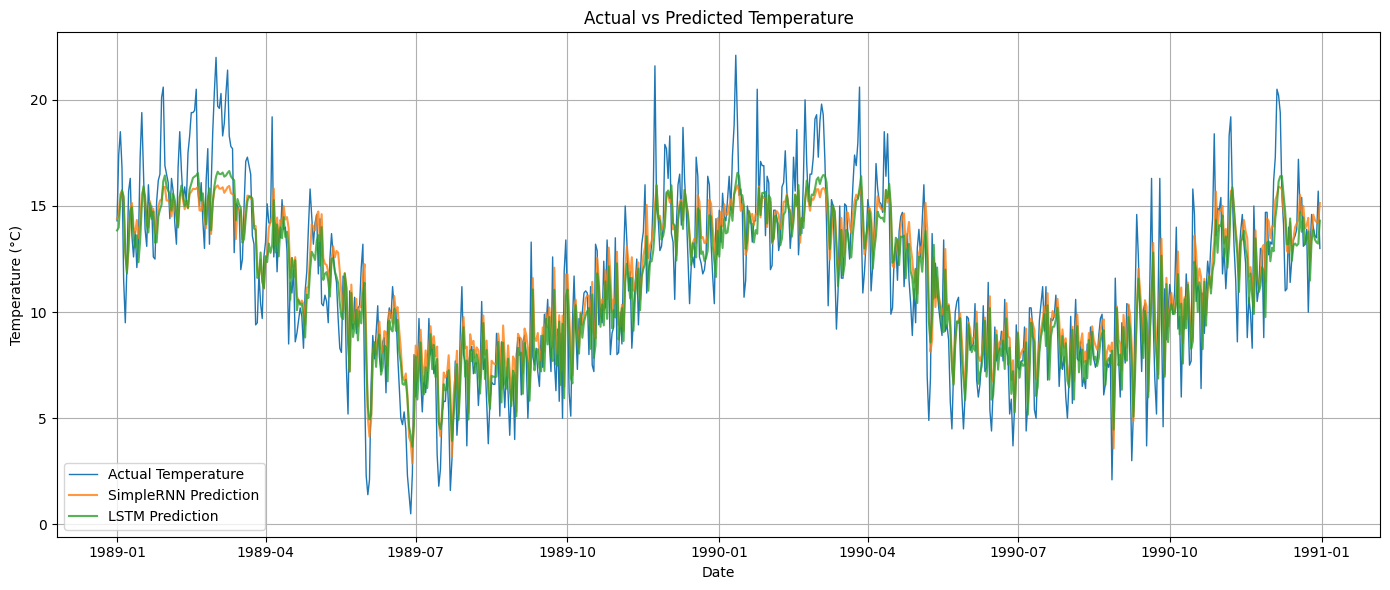

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_data.index,
    y_test,
    label="Actual Temperature",
    linewidth=1
)

plt.plot(
    test_data.index,
    rnn_predictions.flatten(),
    label="SimpleRNN Prediction",
    alpha=0.8
)

plt.plot(
    test_data.index,
    lstm_predictions.flatten(),
    label="LSTM Prediction",
    alpha=0.8
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 12: Save RNN/LSTM Results

The evaluation metrics, training curves, and prediction plot are saved for documentation and future reference.



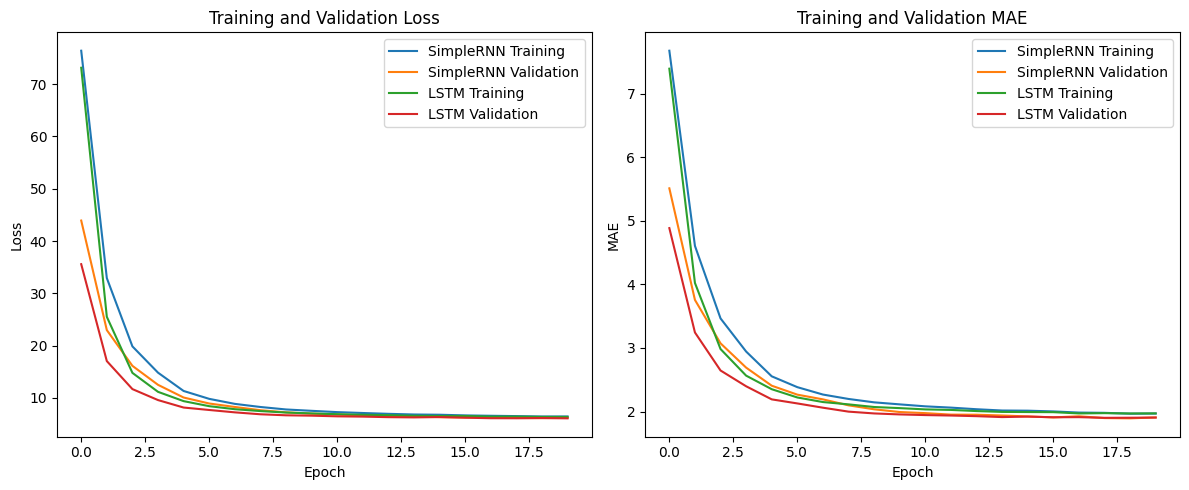

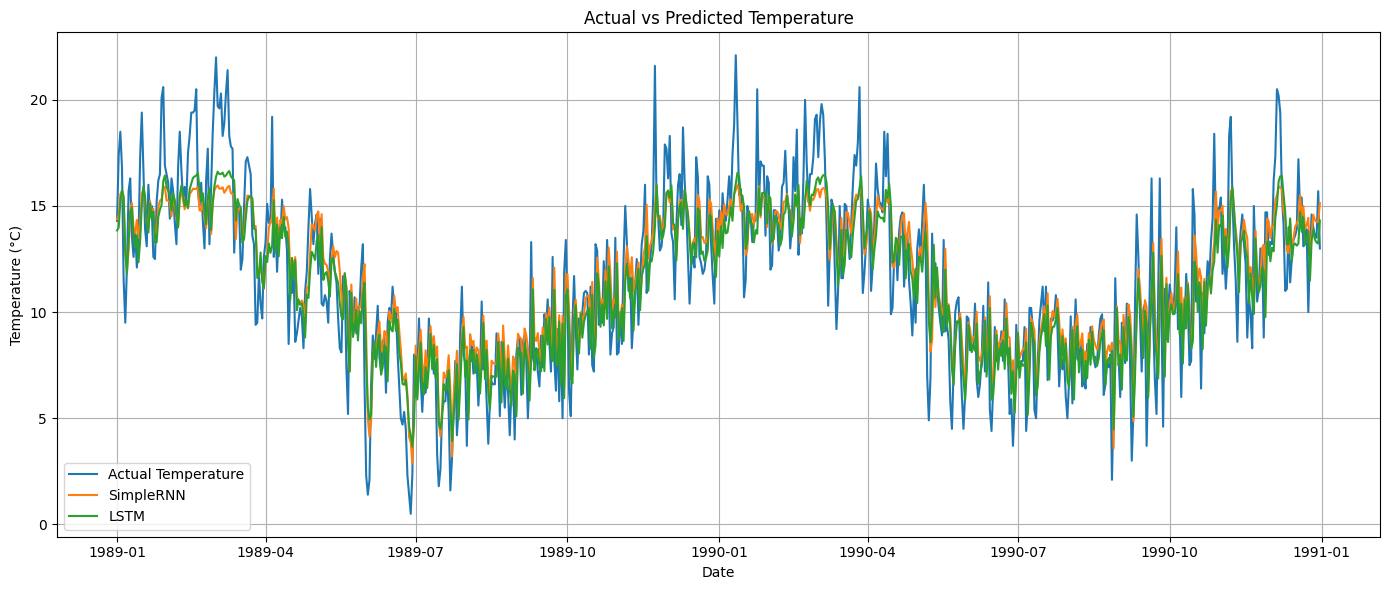

RNN/LSTM results saved successfully!


In [13]:
# Save model comparison
comparison.to_csv("RNN_LSTM_Comparison.csv", index=False)

# Save training and validation curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rnn_history.history["loss"], label="SimpleRNN Training")
plt.plot(rnn_history.history["val_loss"], label="SimpleRNN Validation")
plt.plot(lstm_history.history["loss"], label="LSTM Training")
plt.plot(lstm_history.history["val_loss"], label="LSTM Validation")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rnn_history.history["mae"], label="SimpleRNN Training")
plt.plot(rnn_history.history["val_mae"], label="SimpleRNN Validation")
plt.plot(lstm_history.history["mae"], label="LSTM Training")
plt.plot(lstm_history.history["val_mae"], label="LSTM Validation")
plt.title("Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.savefig("RNN_LSTM_Training_Curves.png", dpi=300, bbox_inches="tight")
plt.show()

# Save prediction graph
plt.figure(figsize=(14, 6))
plt.plot(test_data.index, y_test, label="Actual Temperature")
plt.plot(test_data.index, rnn_predictions.flatten(), label="SimpleRNN")
plt.plot(test_data.index, lstm_predictions.flatten(), label="LSTM")
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("RNN_LSTM_Predictions.png", dpi=300, bbox_inches="tight")
plt.show()

print("RNN/LSTM results saved successfully!")